In [40]:
import os
import zipfile
from urllib.request import urlretrieve

# Завантаження та розархівування датасету
url = "https://github.com/karoldvl/ESC-50/archive/master.zip"
zip_file_path = "ESC-50-master.zip"
download_path = "./ESC-50-master/"
if not os.path.exists(download_path):
    urlretrieve(url, zip_file_path)
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(download_path)
    os.remove(zip_file_path)

In [41]:
import numpy as np
import pandas as pd

In [42]:
def spectrogram(samples, sample_rate, stride_ms=10.0,
                window_ms=20.0, max_freq=None, eps=1e-14):

    stride_size = int(0.001 * sample_rate * stride_ms)
    window_size = int(0.001 * sample_rate * window_ms)

    # Extract strided windows
    truncate_size = (len(samples) - window_size) % stride_size
    samples = samples[:len(samples) - truncate_size]
    nshape = (window_size, (len(samples) - window_size) // stride_size + 1)
    nstrides = (samples.strides[0], samples.strides[0] * stride_size)

    windows = np.lib.stride_tricks.as_strided(
        samples, shape=nshape, strides=nstrides
    )

    assert np.all(windows[:, 1] == samples[stride_size:(stride_size + window_size)])

    # Window weighting, squared FFT, scaling
    weighting = np.hanning(window_size)[:, None]

    fft = np.fft.rfft(windows * weighting, axis=0)
    fft = np.absolute(fft)
    fft = fft ** 2

    scale = np.sum(weighting ** 2) * sample_rate
    fft[1:-1, :] *= (2.0 / scale)
    fft[(0, -1), :] /= scale

    # Frequency list
    freqs = float(sample_rate) / window_size * np.arange(fft.shape[0])

    # Optionally crop by max_freq
    if max_freq is not None:
        ind = np.where(freqs <= max_freq)[0][-1] + 1
        fft = fft[:ind, :]
        freqs = freqs[:ind]

    # Log spectrogram
    specgram = np.log(fft + eps)
    return specgram


In [43]:
def pooling_audio(mat,ksize,method='max',pad=False):
    '''Non-overlapping pooling on 2D or 3D data.

    <mat>: ndarray, input array to pool.
    <ksize>: tuple of 2, kernel size in (ky, kx).
    <method>: str, 'max for max-pooling,
                   'mean' for mean-pooling.
    <pad>: bool, pad <mat> or not. If no pad, output has size
           n//f, n being <mat> size, f being kernel size.
           if pad, output has size ceil(n/f).

    Return <result>: pooled matrix.
    '''

    m, n = mat.shape[:2]
    ky,kx=ksize

    _ceil=lambda x,y: int(np.ceil(x/float(y)))

    if pad:
        ny=_ceil(m,ky)
        nx=_ceil(n,kx)
        size=(ny*ky, nx*kx)+mat.shape[2:]
        mat_pad=np.full(size,np.nan)
        mat_pad[:m,:n,...]=mat
    else:
        ny=m//ky
        nx=n//kx
        mat_pad=mat[:ny*ky, :nx*kx, ...]

    new_shape=(ny,ky,nx,kx)+mat.shape[2:]

    if method=='max':
        result=np.nanmax(mat_pad.reshape(new_shape),axis=(1,3))
    else:
        result=np.nanmean(mat_pad.reshape(new_shape),axis=(1,3))

    return result


In [64]:
import librosa


base = "ESC-50-master/ESC-50-master"

df = pd.read_csv(f"{base}/meta/esc50.csv")

X = []
y = []

dogs, birds = 0, 0
df_small = df[df.category.isin(["dog", "chirping_birds"])].copy()

for row in df_small.itertuples():
    samples, sr = librosa.load(f"{base}/audio/{row.filename}", sr=None)
    spec = spectrogram(samples, sr)

    window_size = (2, 2) # Зменшуємо розмір даних
    spec_pooled = pooling_audio(spec, window_size)
    feature_vector = spec_pooled.flatten()

    X.append(feature_vector)
    y.append(row.category)
    if row.category == 'dog':
      dogs += 1
    else:
      birds += 1

print(f'dogs = {dogs}, birds = {birds}')
X = np.array(X)
y = np.array(y)

dogs = 40, birds = 40


In [90]:
# Для спектрограм іноді краще працює:
from sklearn.preprocessing import MinMaxScaler
#from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import RobustScaler

# Масштабування ознак
scaler = MinMaxScaler()
#scaler = StandardScaler()
#scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.cluster import SpectralClustering

model = SpectralClustering(
    n_clusters=2,
    n_neighbors = 10,
    affinity='nearest_neighbors',
    assign_labels='kmeans',
    random_state=42
)
clusters = model.fit_predict(X_scaled)

In [91]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(y, clusters)
print(f"Adjusted Rand Index: {ari:.2f}")

Adjusted Rand Index: 0.42


In [92]:
import pandas as pd

results = pd.DataFrame({
    "true_label": y,
    "cluster": clusters
})

#print(results.head(10))
#print()
print(pd.crosstab(results["true_label"], results["cluster"]))

cluster          0   1
true_label            
chirping_birds   9  31
dog             35   5


Показуємо які екземпляри були віднесені до якого кластеру

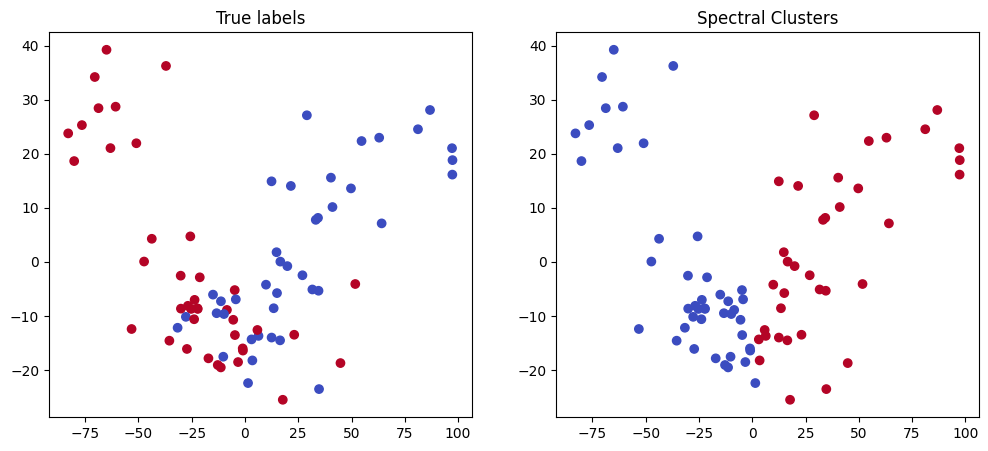

In [93]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

X_2d = PCA(n_components=2).fit_transform(X_scaled)
fig, ax = plt.subplots(1,2,figsize=(12,5))

from matplotlib.lines import Line2D

ax[0].scatter(X_2d[:,0], X_2d[:,1], c=(np.array(y)=="dog"), cmap="coolwarm")
ax[0].set_title("True labels")

ax[1].scatter(X_2d[:,0], X_2d[:,1], c=clusters, cmap="coolwarm")
ax[1].set_title("Spectral Clusters")

plt.show()

**Висновок**

У рамках дослідження було виконано кластеризацію аудіозаписів з набору даних ESC-50 для двох категорій звуків: dog та chirping_birds. Для аналізу було відібрано 80 аудіозаписів, з яких 40 записів належать до класу dog та 40 записів до класу chirping_birds. Таким чином, вибірка була збалансованою, що дозволило об’єктивно оцінити результати кластеризації.

Для формування ознак аудіосигнали були перетворені у спектрограми, які відображають розподіл енергії сигналу в часі та частоті. Далі до спектрограм було застосовано операцію pooling, яка дозволяє зменшити розмір матриці та узагальнити локальні спектральні характеристики. Після цього спектрограми були перетворені у вектори ознак за допомогою операції flatten, що дозволило використовувати алгоритм SpectralClustering для групування аудіозаписів.

Одним із ключових етапів експерименту було дослідження впливу розміру pooling-вікна на якість кластеризації. Спочатку було використано велике вікно (20×20). У цьому випадку значна частина локальної спектральної інформації усереднюється, що призводить до втрати деяких важливих характеристик звукового сигналу. Для цього параметра при використанні MinMaxScaler було отримано наступний розподіл кластерів:

```
true label      cluster 0  cluster 1

chirping_birds      12         28

dog                 36         4
```

Це означає, що більшість записів dog були віднесені до кластера 0, а більшість chirping_birds — до кластера 1. Проте частина аудіозаписів була класифікована неправильно через втрату спектральних деталей при великому pooling-вікні. Показник Adjusted Rand Index = 0.35.

У наступному експерименті розмір pooling-вікна було зменшено до (2×2). Менший розмір pooling дозволяє зберегти більше локальної інформації про структуру спектра та часові зміни сигналу. У результаті якість кластеризації покращилась, і було отримано наступний розподіл:

```
true label	    cluster 0	cluster 1

chirping_birds	9	        31

dog	            35	      5
```

У цьому випадку більшість записів chirping_birds потрапили до другого кластера, а записи dog — до першого. Це свідчить про більш чітке розділення класів у просторі ознак. Відповідно, показник Adjusted Rand Index зріс приблизно до 0.42, що підтверджує покращення якості кластеризації при використанні меншого pooling-вікна.

Крім того, було проведено порівняння різних методів масштабування ознак. Було протестовано MinMaxScaler, StandardScaler та RobustScaler. Найкращий результат показав MinMaxScaler, для якого частка правильно згрупованих аудіозаписів становила 82,5%. Для StandardScaler цей показник склав 80%, а для RobustScaler — 78,75%. Це свідчить про те, що MinMaxScaler краще зберігає відносні відмінності між спектральними характеристиками аудіосигналів у даній задачі.

Таким чином, результати експерименту показали, що якість кластеризації значною мірою залежить від параметрів попередньої обробки даних. Менший розмір pooling-вікна дозволяє зберегти більше спектральної інформації, а використання MinMaxScaler забезпечує більш ефективне масштабування ознак. Поєднання цих підходів дозволило отримати найкращу якість кластеризації для аудіокласів dog та chirping_birds у вибірці з 80 звукових записів.